# Credit Risk Analytics — Data Understanding & EDA

## 1. Business Objective

This notebook analyzes 150,000 consumer credit records to identify risk patterns associated with future serious delinquency.

The analysis focuses on four questions:

1. Does prior delinquency history relate to future serious delinquency?
2. Does higher revolving credit utilization correspond to higher risk?
3. Does debt burden show a relationship with future delinquency?
4. Do multiple adverse risk signals accumulate into substantially higher risk?

Python is used for data understanding, cleaning, exploratory analysis, and statistical validation. PostgreSQL is used later to operationalize the cleaned risk logic and analytical views.

In [120]:
import pandas as pd 
import numpy as np

In [61]:
df = pd.read_csv("../data/cs-training.csv", index_col=0)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 150000
Columns: 11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Data Loading & Overview

The dataset contains 150,000 customer records and 12 variables, including the target variable `SeriousDlqin2yrs`.

The target represents whether a customer experienced serious delinquency within two years.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
df.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1500.990000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
5%,7500.950000,0.000000,0.000000,29.000000,0.000000,0.004329,1.300000e+03,2.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
95%,142500.050000,1.000000,1.000000,78.000000,2.000000,2449.000000,1.458760e+04,18.000000,1.000000,3.000000,1.000000,3.000000


## 3. Data Quality Assessment

Before modeling or risk segmentation, the dataset is assessed for:

- missing values
- duplicate records
- invalid values
- suspicious delinquency codes
- extreme financial ratios

In [9]:
print('missing_count:', df.isnull().sum())
print('missing_pct:', df.isnull().mean()*100)

missing_count: Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64
missing_pct: Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberO

### Finding

`MonthlyIncome` has 29,731 missing values (19.82%), while `NumberOfDependents` has 3,924 missing values (2.62%). Missing income will be retained as an explicit analytical dimension because its availability is later found to materially affect interpretation of extreme `DebtRatio` values.

In [12]:
df.duplicated().sum()
df['Unnamed: 0'].duplicated().sum()

np.int64(0)

### Duplicate Check

No duplicate customer records were identified based on the full row and the source identifier.

In [13]:
print('Count:', df['SeriousDlqin2yrs'].value_counts())
print('Percentage:', df['SeriousDlqin2yrs'].value_counts(normalize=True)*100)

Count: SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
Percentage: SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


### Target Distribution

The target is imbalanced: 6.68% of customers experienced serious delinquency, while 93.32% did not.

This portfolio-level default rate will be used as the baseline for risk-ratio comparisons.

In [20]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(col, "negative values:", (df[col] < 0).sum())
        print(col, "zero values:", (df[col] == 0).sum())

Unnamed: 0 negative values: 0
Unnamed: 0 zero values: 0
SeriousDlqin2yrs negative values: 0
SeriousDlqin2yrs zero values: 139974
RevolvingUtilizationOfUnsecuredLines negative values: 0
RevolvingUtilizationOfUnsecuredLines zero values: 10878
age negative values: 0
age zero values: 1
NumberOfTime30-59DaysPastDueNotWorse negative values: 0
NumberOfTime30-59DaysPastDueNotWorse zero values: 126018
DebtRatio negative values: 0
DebtRatio zero values: 4113
MonthlyIncome negative values: 0
MonthlyIncome zero values: 1634
NumberOfOpenCreditLinesAndLoans negative values: 0
NumberOfOpenCreditLinesAndLoans zero values: 1888
NumberOfTimes90DaysLate negative values: 0
NumberOfTimes90DaysLate zero values: 141662
NumberRealEstateLoansOrLines negative values: 0
NumberRealEstateLoansOrLines zero values: 56188
NumberOfTime60-89DaysPastDueNotWorse negative values: 0
NumberOfTime60-89DaysPastDueNotWorse zero values: 142396
NumberOfDependents negative values: 0
NumberOfDependents zero values: 86902


No negative values were identified. Zero values are present in several variables and are treated according to their business meaning rather than automatically classified as missing.

In [21]:
df[df['age']==0]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [22]:
cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in cols: 
    print(df[col].value_counts().sort_index().tail(15))


NumberOfTime30-59DaysPastDueNotWorse
1     16033
2      4598
3      1754
4       747
5       342
6       140
7        54
8        25
9        12
10        4
11        1
12        2
13        1
96        5
98      264
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64
NumberOfTimes90DaysLate
4     291
5     131
6      80
7      38
8      21
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64


### Suspicious Delinquency Codes

The three delinquency-history variables contain unusually high values of `96` and `98`.

Because these values are inconsistent with normal delinquency-count behavior, they are treated as invalid/suspicious codes and replaced with missing values in the cleaned dataset.

In [23]:
df.loc[
    df['RevolvingUtilizationOfUnsecuredLines'] > 10,
    ['SeriousDlqin2yrs',
     'RevolvingUtilizationOfUnsecuredLines',
     'age',
     'DebtRatio',
     'MonthlyIncome']
].describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome
count,241.000000,241.000000,241.000000,241.000000,173.00000
mean,0.070539,3564.023932,50.630705,571.918644,8467.67052
std,0.256587,5123.802683,14.565389,1772.948412,6564.06825
min,0.000000,11.385230,24.000000,0.000800,0.00000
25%,0.000000,941.000000,39.000000,0.217813,4500.00000
50%,0.000000,2012.000000,48.000000,0.402560,7000.00000
75%,0.000000,4116.000000,62.000000,59.000000,10091.00000
max,1.000000,50708.000000,87.000000,21395.000000,44472.00000


In [24]:
df.loc[
    df['DebtRatio'] > 10,
    ['SeriousDlqin2yrs',
     'DebtRatio',
     'age',
     'MonthlyIncome']
].describe()

,SeriousDlqin2yrs,DebtRatio,age,MonthlyIncome
count,28877.000000,28877.000000,28877.000000,2106.000000
mean,0.055719,1831.909066,55.292551,118.451567
std,0.229382,4343.144572,14.726018,962.739430
min,0.000000,10.138614,21.000000,0.000000
25%,0.000000,373.000000,45.000000,0.000000
50%,0.000000,1341.000000,56.000000,0.000000
75%,0.000000,2503.000000,65.000000,1.000000
max,1.000000,329664.000000,109.000000,16500.000000


In [25]:
df['IncomeStatus'] = np.select([df['MonthlyIncome'].isna(), df['MonthlyIncome'] == 0], ['Missing','Zero'], default='Reported')
income_risk = df.groupby('IncomeStatus')['SeriousDlqin2yrs'].agg(customers='count',default_rate='mean')
print(income_risk)

              customers  default_rate
IncomeStatus                         
Missing           29731      0.056137
Reported         118635      0.069887
Zero               1634      0.040392


In [33]:
df.groupby('IncomeStatus')['SeriousDlqin2yrs'].agg(['count', 'sum', 'mean'])

,count,sum,mean
IncomeStatus,,,
Missing,29731,1669,0.056137
Reported,118635,8291,0.069887
Zero,1634,66,0.040392


In [27]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['IncomeStatus'], df['SeriousDlqin2yrs'])
print(contingency_table)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("chi2:", chi2) 
print('p-value:', p_value) 
print('dof:', dof)

SeriousDlqin2yrs       0     1
IncomeStatus                  
Missing            28062  1669
Reported          110344  8291
Zero                1568    66
chi2: 90.58772393867713
p-value: 2.1336622948960988e-20
dof: 2


In [28]:
n = contingency_table.to_numpy().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
print('cramers_v:', cramers_v)

cramers_v: 0.0245747463789798


In [29]:
income_debt = df.groupby('IncomeStatus')['DebtRatio'].agg(median='median', mean='mean', p75=lambda x: x.quantile(0.75), p95=lambda x: x.quantile(0.95))
print(income_debt)

                   median         mean          p75          p95
IncomeStatus                                                    
Missing       1159.000000  1673.396556  2382.000000  4902.500000
Reported         0.292454     5.291856     0.473289     0.982385
Zero           930.000000  1573.567319  2185.250000  4896.700000


In [30]:
pd.crosstab(
    df['IncomeStatus'],
    df['DebtRatio'] > 10,
    normalize='index'
) * 100

DebtRatio,False,True
IncomeStatus,,
Missing,9.955938,90.044062
Reported,99.444515,0.555485
Zero,11.444308,88.555692


In [31]:
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate']

results = {}
for col in delinquency_cols:
    results[col] = df.groupby(col)['SeriousDlqin2yrs'].agg(
              customers='count',
              defaults='sum',
              default_rate='mean')
for col, profile in results.items():
    print(f"Risk profile for {col}:")
    print(profile, "\n")

Risk profile for NumberOfTime30-59DaysPastDueNotWorse:
                                      customers  defaults  default_rate
NumberOfTime30-59DaysPastDueNotWorse                                   
0                                        126018      5041      0.040002
1                                         16033      2409      0.150253
2                                          4598      1219      0.265115
3                                          1754       618      0.352338
4                                           747       318      0.425703
5                                           342       154      0.450292
6                                           140        74      0.528571
7                                            54        28      0.518519
8                                            25         8      0.320000
9                                            12         4      0.333333
10                                            4         3      0.750000
11       

## 4. Data Cleaning

The cleaned dataset preserves the original records while standardizing suspicious values and tracking missingness explicitly.

Cleaning rules:

- `age = 0` → missing → median imputation
- delinquency codes `96/98` → missing
- `MonthlyIncome` missingness → retained and flagged
- `NumberOfDependents` missingness → flagged, then median-imputed
- raw source identifier removed after validation

In [34]:
df_clean=df.copy()

In [35]:
df_clean.loc[df_clean['age'] == 0, 'age'] = np.nan

In [36]:
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in delinquency_cols:
    df_clean[col] = df_clean[col].replace([96, 98], np.nan)

In [37]:
df_clean['MonthlyIncome_missing'] = (
    df_clean['MonthlyIncome'].isna().astype(int)
)

In [40]:
df_clean['IncomeStatus'] = np.select([df_clean['MonthlyIncome'].isna(),df_clean['MonthlyIncome'] == 0],['Missing','Zero'],default='Reported')

In [41]:
df_clean.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         1
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                       3924
IncomeStatus                                0
MonthlyIncome_missing                       0
dtype: int64

In [42]:
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

df_clean[df_clean[delinquency_cols].isna().any(axis=1)][
    delinquency_cols + ['SeriousDlqin2yrs']
].head(20)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1733,NaN,NaN,NaN,1
2286,NaN,NaN,NaN,0
3884,NaN,NaN,NaN,0
4417,NaN,NaN,NaN,0
4705,NaN,NaN,NaN,0
5073,NaN,NaN,NaN,0
6280,NaN,NaN,NaN,1
7032,NaN,NaN,NaN,1
7117,NaN,NaN,NaN,1
7687,NaN,NaN,NaN,1


In [43]:
df_clean[delinquency_cols].isna().all(axis=1).sum()

np.int64(269)

In [44]:
df_clean['age'] = df_clean['age'].fillna(
    df_clean['age'].median())

In [45]:
df_clean['NumberOfDependents_missing'] = (
    df_clean['NumberOfDependents'].isna().astype(int)
)

In [46]:
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(
    df_clean['NumberOfDependents'].median()
)

In [58]:
df_clean.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                          0
IncomeStatus                                0
MonthlyIncome_missing                       0
NumberOfDependents_missing                  0
DelinquencyHistory_missing                  0
DebtRatio_Valid                         31365
dtype: int64

In [57]:
df_clean['DelinquencyHistory_missing'] = (
    df_clean[delinquency_cols].isna().all(axis=1).astype(int)
)

In [56]:
df_clean['DebtRatio_Valid'] = np.where(
    df_clean['IncomeStatus'] == 'Reported',
    df_clean['DebtRatio'],
    np.nan
)

In [62]:
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nTarget distribution:")
print(df_clean['SeriousDlqin2yrs'].value_counts())
print(df_clean['SeriousDlqin2yrs'].value_counts(normalize=True) * 100)

Shape: (150000, 16)

Missing values:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                          0
IncomeStatus                                0
MonthlyIncome_missing                       0
NumberOfDependents_missing                  0
DelinquencyHistory_missing                  0
DebtRatio_Valid                         31365
dtype: int64

Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


### Cleaning Validation

After cleaning, missingness remains only where the information is analytically meaningful:

- `MonthlyIncome`
- the three delinquency variables affected by suspicious `96/98` codes

Imputed fields are complete.

## 5. R1 — Delinquency Risk

### Business Question

Does prior delinquency history associate with future serious delinquency?

The analysis examines 30–59 day, 60–89 day, and 90+ day delinquency histories. The 90+ DPD measure is later selected as the primary behavioral risk signal for combined-risk segmentation.

In [63]:
df_clean['90Late_Band'] = pd.cut( df_clean['NumberOfTimes90DaysLate'], bins=[-1, 0, 1, float('inf')],labels=['0', '1', '2+'])

In [64]:
risk_90late = df_clean.groupby('90Late_Band', observed=False)['SeriousDlqin2yrs'].agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )


risk_90late['default_rate'] *= 100

print(risk_90late)

             customers  defaults  default_rate
90Late_Band                                   
0               141662      6554      4.626505
1                 5243      1765     33.663933
2+                2826      1560     55.201699


In [66]:
baseline = df_clean['SeriousDlqin2yrs'].mean()
risk_90late['risk_ratio'] = (
    risk_90late['default_rate'] / (baseline * 100)
)

print(baseline)
print(risk_90late)


0.06684
             customers  defaults  default_rate  risk_ratio
90Late_Band                                               
0               141662      6554      4.626505    0.692176
1                 5243      1765     33.663933    5.036495
2+                2826      1560     55.201699    8.258782


### Key Finding

Future serious delinquency rises sharply with prior 90+ day delinquency history.

Customers with 2+ prior 90-day delinquencies show a 55.20% observed default rate, compared with 4.63% among customers with no prior 90+ delinquency. This corresponds to an observed risk ratio of 8.26× the portfolio baseline.

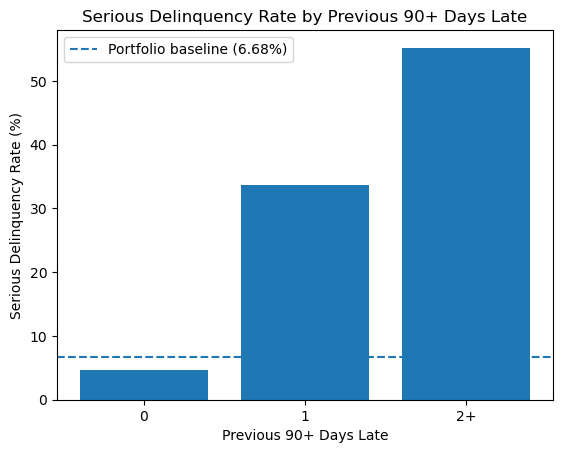

In [67]:
import matplotlib.pyplot as plt 
plt.bar(risk_90late.index.astype(str), risk_90late['default_rate'])
plt.axhline(
    baseline * 100,
    linestyle='--',
    label=f'Portfolio baseline ({baseline * 100:.2f}%)')
plt.xlabel('Previous 90+ Days Late')
plt.ylabel('Serious Delinquency Rate (%)')
plt.title('Serious Delinquency Rate by Previous 90+ Days Late')
plt.legend()

plt.show()

In [68]:
from scipy.stats import chi2_contingency 
contingency_90late = pd.crosstab(
    df_clean['90Late_Band'],
    df_clean['SeriousDlqin2yrs']
)
print(contingency_90late) 
chi2, p_value, dof, expected = chi2_contingency(contingency_90late)
print('chi2:', chi2) 
print('p_value:', p_value) 
print('dof:', dof)

SeriousDlqin2yrs       0     1
90Late_Band                   
0                 135108  6554
1                   3478  1765
2+                  1266  1560
chi2: 17959.15560871413
p_value: 0.0
dof: 2


In [69]:
n = contingency_90late.to_numpy().sum()
phi2 = chi2 / n

r, k = contingency_90late.shape

cramers_v = np.sqrt(
    phi2 / min(k - 1, r - 1)
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.3463275927241221


#Prior 90+ day delinquency is strongly associated with future serious delinquency risk. Customers with one prior 90+ DPD event have a 33.7% observed default rate, while customers with 2+ events have a 55.2% rate, compared with 4.6% among customers with no prior 90+ DPD. The association is statistically significant (χ² ≈ 17,959, p < 0.001) with a moderate Cramér's V of 0.346.

In [70]:
df_clean['30-59Late_Band'] = pd.cut( df_clean['NumberOfTime30-59DaysPastDueNotWorse'], bins=[-1, 0, 1, 2, float('inf')],labels=['0', '1', '2','3+'])

In [71]:
risk_30_59 = df_clean.groupby('30-59Late_Band', observed=False)['SeriousDlqin2yrs'].agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )


risk_30_59['default_rate'] *= 100

print(risk_30_59)

                customers  defaults  default_rate
30-59Late_Band                                   
0                  126018      5041      4.000222
1                   16033      2409     15.025260
2                    4598      1219     26.511527
3+                   3082      1210     39.260221


In [72]:
baseline = df_clean['SeriousDlqin2yrs'].mean()
risk_30_59['risk_ratio'] = (
    risk_30_59['default_rate'] / (baseline * 100)
)

print(baseline)
print(risk_30_59)

0.06684
                customers  defaults  default_rate  risk_ratio
30-59Late_Band                                               
0                  126018      5041      4.000222    0.598477
1                   16033      2409     15.025260    2.247944
2                    4598      1219     26.511527    3.966416
3+                   3082      1210     39.260221    5.873761


In [74]:
df_clean['60_89Late_Band'] = pd.cut(
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'],
    bins=[-1, 0, 1, 2, float('inf')],
    labels=['0', '1', '2', '3+']
)

In [75]:
risk_60_89 = df_clean.groupby('60_89Late_Band', observed=False)['SeriousDlqin2yrs'].agg(
    customers='count',
    defaults='sum',
    default_rate='mean')

risk_60_89['default_rate'] *= 100

risk_60_89['risk_ratio'] = (
    risk_60_89['default_rate'] / (baseline * 100)
)

print(risk_60_89)

                customers  defaults  default_rate  risk_ratio
60_89Late_Band                                               
0                  142396      7256      5.095649    0.762365
1                    5731      1777     31.006805    4.638959
2                    1118       561     50.178891    7.507315
3+                    486       285     58.641975    8.773485


In [76]:
baseline = df_clean['SeriousDlqin2yrs'].mean()
risk_60_89['risk_ratio'] = (
    risk_60_89['default_rate'] / (baseline * 100)
)

print(baseline)
print(risk_60_89)

0.06684
                customers  defaults  default_rate  risk_ratio
60_89Late_Band                                               
0                  142396      7256      5.095649    0.762365
1                    5731      1777     31.006805    4.638959
2                    1118       561     50.178891    7.507315
3+                    486       285     58.641975    8.773485


In [77]:
from scipy.stats import chi2_contingency

contingency_30_59 = pd.crosstab(
    df_clean['30-59Late_Band'],
    df_clean['SeriousDlqin2yrs']
)

print(contingency_30_59)

chi2_30, p_30, dof_30, expected_30 = chi2_contingency(
    contingency_30_59
)

print("Chi-square:", chi2_30)
print("p-value:", p_30)
print("dof:", dof_30)

SeriousDlqin2yrs       0     1
30-59Late_Band                
0                 120977  5041
1                  13624  2409
2                   3379  1219
3+                  1872  1210
Chi-square: 11521.81695851491
p-value: 0.0
dof: 3


In [78]:
n_30 = contingency_30_59.to_numpy().sum()

phi2_30 = chi2_30 / n_30

r_30, k_30 = contingency_30_59.shape

cramers_v_30 = np.sqrt(
    phi2_30 / min(k_30 - 1, r_30 - 1)
)

print("Cramér's V:", cramers_v_30)

Cramér's V: 0.2773988288628651


In [79]:
contingency_60_89 = pd.crosstab(
    df_clean['60_89Late_Band'],
    df_clean['SeriousDlqin2yrs']
)

print(contingency_60_89)

chi2_60, p_60, dof_60, expected_60 = chi2_contingency(
    contingency_60_89
)

print("Chi-square:", chi2_60)
print("p-value:", p_60)
print("dof:", dof_60)

SeriousDlqin2yrs       0     1
60_89Late_Band                
0                 135140  7256
1                   3954  1777
2                    557   561
3+                   201   285
Chi-square: 11644.015430931286
p-value: 0.0
dof: 3


In [80]:
n_60 = contingency_60_89.to_numpy().sum()

phi2_60 = chi2_60 / n_60

r_60, k_60 = contingency_60_89.shape

cramers_v_60 = np.sqrt(
    phi2_60 / min(k_60 - 1, r_60 - 1)
)

print("Cramér's V:", cramers_v_60)

Cramér's V: 0.278865971951705


In [82]:
util = df_clean['RevolvingUtilizationOfUnsecuredLines'] 
print(util.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995]))

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
1%            0.000000
5%            0.000000
25%           0.029867
50%           0.154181
75%           0.559046
90%           0.981278
95%           1.000000
99%           1.092956
99.5%         1.366269
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [83]:
print("Value > 1:", (util>1).sum())
print("Value > 2:", (util>2).sum())
print("Value > 5:", (util>5).sum())
print("Value > 10:", (util>10).sum())

Value > 1: 3321
Value > 2: 371
Value > 5: 254
Value > 10: 241


In [84]:
df_clean['Utilization_Band'] = pd.cut(df_clean['RevolvingUtilizationOfUnsecuredLines'], 
                                      bins = [-0.001, 0, 0.3, 0.7, 1, 2, float('inf')], 
                                       labels=['0', '0-30%', '30-70%', '70-100%', '100-200%', '200%+'])

In [85]:
risk_util = df_clean.groupby('Utilization_Band', observed=False)['SeriousDlqin2yrs'].agg(customers='count',
    defaults='sum',
    default_rate='mean')
print(risk_util)

                  customers  defaults  default_rate
Utilization_Band                                   
0                     10878       320      0.029417
0-30%                 82004      1741      0.021231
30-70%                27170      2011      0.074015
70-100%               26627      4717      0.177151
100-200%               2950      1183      0.401017
200%+                   371        54      0.145553


In [86]:
risk_util['default_rate']*=100 
baseline = df_clean['SeriousDlqin2yrs'].mean()
risk_util['risk_ratio'] = (
    risk_util['default_rate'] / (baseline * 100)
)
print(risk_util)

                  customers  defaults  default_rate  risk_ratio
Utilization_Band                                               
0                     10878       320      2.941717    0.440113
0-30%                 82004      1741      2.123067    0.317634
30-70%                27170      2011      7.401546    1.107353
70-100%               26627      4717     17.715101    2.650374
100-200%               2950      1183     40.101695    5.999655
200%+                   371        54     14.555256    2.177627


In [119]:
from scipy.stats import chi2_contingency 
contingency_util = pd.crosstab(df_clean['Utilization_Band'], df_clean['SeriousDlqin2yrs'])
print(contingency_util)

SeriousDlqin2yrs      0     1
Utilization_Band             
0                 10558   320
0-30%             80263  1741
30-70%            25159  2011
70-100%           21910  4717
100-200%           1767  1183
200%+               317    54


In [88]:
chi2, p_value, dof, expected = chi2_contingency(contingency_util)
print("Chi2:", chi2) 
print("p_value:", p_value) 
print("dof:", dof) 

Chi2: 3.8429533326319234
p_value: 0.5722412658637096
dof: 5


In [89]:
n_util = contingency_util.to_numpy().sum() 
phi2_util = chi2/ n_util

r_util, k_util = contingency_util.shape

cramers_v_util = np.sqrt(
    phi2_util / min(k_util - 1, r_util - 1)
)

print("Cramer's V:", cramers_v_util)

Cramer's V: 0.005061606433068199


In [90]:
df_clean.loc[
    df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10,
    [
        'RevolvingUtilizationOfUnsecuredLines',
        'SeriousDlqin2yrs',
        'age',
        'DebtRatio',
        'MonthlyIncome',
        'NumberOfOpenCreditLinesAndLoans'
    ]
].sort_values(
    'RevolvingUtilizationOfUnsecuredLines',
    ascending=False
).head(20)

,RevolvingUtilizationOfUnsecuredLines,SeriousDlqin2yrs,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans
85489,50708.0,0,55.0,0.221757,38000.0,7
31414,29110.0,0,58.0,0.402560,10000.0,7
16956,22198.0,0,38.0,2312.000000,NaN,5
149160,22000.0,0,38.0,1.080020,3973.0,7
149279,20514.0,0,42.0,0.062102,9902.0,1
117315,18300.0,0,45.0,0.221582,12500.0,5
21978,17441.0,0,51.0,0.354072,14770.0,14
124533,13930.0,0,45.0,4902.000000,NaN,4
72592,13498.0,0,38.0,0.347428,4800.0,6
71705,13400.0,0,43.0,0.995801,5000.0,11


In [91]:
extreme_util = df_clean[
    df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10
]

print("Customers:", len(extreme_util))
print("Defaults:", extreme_util['SeriousDlqin2yrs'].sum())
print(
    "Default rate:",
    extreme_util['SeriousDlqin2yrs'].mean() * 100
)

Customers: 241
Defaults: 17
Default rate: 7.053941908713693


In [101]:
normal_util = df_clean[df_clean['RevolvingUtilizationOfUnsecuredLines'] <= 10]

print("Customers:", len(normal_util))
print("Defaults:", normal_util['SeriousDlqin2yrs'].sum())
print(
    "Default rate:",
    normal_util['SeriousDlqin2yrs'].mean() * 100
)

Customers: 149759
Defaults: 10009
Default rate: 6.683404670170074


In [93]:
print(
    df_clean[
        df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10
    ]['RevolvingUtilizationOfUnsecuredLines'].describe()
)

count      241.000000
mean      3564.023932
std       5123.802683
min         11.385230
25%        941.000000
50%       2012.000000
75%       4116.000000
max      50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [94]:
print(df_clean[df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10][
        [
            'RevolvingUtilizationOfUnsecuredLines',
            'SeriousDlqin2yrs',
            'age',
            'DebtRatio',
            'MonthlyIncome',
            'NumberOfOpenCreditLinesAndLoans'
        ]
    ].sort_values(
        'RevolvingUtilizationOfUnsecuredLines',
        ascending=False
    ).head(20)
)

        RevolvingUtilizationOfUnsecuredLines  SeriousDlqin2yrs   age  \
85489                                50708.0                 0  55.0   
31414                                29110.0                 0  58.0   
16956                                22198.0                 0  38.0   
149160                               22000.0                 0  38.0   
149279                               20514.0                 0  42.0   
117315                               18300.0                 0  45.0   
21978                                17441.0                 0  51.0   
124533                               13930.0                 0  45.0   
72592                                13498.0                 0  38.0   
71705                                13400.0                 0  43.0   
125718                               12369.0                 0  40.0   
58852                                11843.0                 0  45.0   
83052                                11553.0                 0  

In [102]:
extreme_util = df_clean[
    df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10
]

extreme_summary = extreme_util[
    [
        'RevolvingUtilizationOfUnsecuredLines',
        'DebtRatio',
        'MonthlyIncome',
        'NumberOfOpenCreditLinesAndLoans',
        'SeriousDlqin2yrs'
    ]
].describe()

print(extreme_summary)

       RevolvingUtilizationOfUnsecuredLines     DebtRatio  MonthlyIncome  \
count                            241.000000    241.000000      173.00000   
mean                            3564.023932    571.918644     8467.67052   
std                             5123.802683   1772.948412     6564.06825   
min                               11.385230      0.000800        0.00000   
25%                              941.000000      0.217813     4500.00000   
50%                             2012.000000      0.402560     7000.00000   
75%                             4116.000000     59.000000    10091.00000   
max                            50708.000000  21395.000000    44472.00000   

       NumberOfOpenCreditLinesAndLoans  SeriousDlqin2yrs  
count                       241.000000        241.000000  
mean                          5.763485          0.070539  
std                           3.114160          0.256587  
min                           1.000000          0.000000  
25%                 

In [95]:
print(
    extreme_util[
        [
            'MonthlyIncome',
            'DebtRatio',
            'NumberOfOpenCreditLinesAndLoans'
        ]
    ].isnull().sum()
)

MonthlyIncome                      68
DebtRatio                           0
NumberOfOpenCreditLinesAndLoans     0
dtype: int64


In [103]:
df_clean['Utilization_Extreme'] = (
    df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10
).astype(int)

In [104]:
print(df_clean['Utilization_Extreme'].value_counts())

Utilization_Extreme
0    149759
1       241
Name: count, dtype: int64


### Key Finding

The utilization distribution is highly right-skewed. A small set of 241 observations exceeds 10 and contains extreme values up to 50,708. These observations are retained and flagged rather than automatically removed because their observed default rate (7.05%) is close to the portfolio baseline.

In [105]:
debt = df_clean['DebtRatio']
print(debt.describe(percentiles=[0.01, 0.05, 0.25, 0.50,
            0.75, 0.90, 0.95, 0.99, 0.995]))

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
1%            0.000000
5%            0.004329
25%           0.175074
50%           0.366508
75%           0.868254
90%        1267.000000
95%        2449.000000
99%        4979.040000
99.5%      6186.010000
max      329664.000000
Name: DebtRatio, dtype: float64


In [100]:
print("Values > 1:", (debt > 1).sum())
print("Values > 2:", (debt > 2).sum())
print("Values > 5:", (debt > 5).sum())
print("Values > 10:", (debt > 10).sum())
print("Values > 100:", (debt > 100).sum())

Values > 1: 35137
Values > 2: 31045
Values > 5: 29646
Values > 10: 28877
Values > 100: 24380


In [106]:
debt_high = df_clean[df_clean['DebtRatio'] > 1]

print("Customers:", len(debt_high))

print("Null:",debt_high['MonthlyIncome'].isnull().sum())
print("Missing income rate:",debt_high['MonthlyIncome'].isnull().mean() * 100)

Customers: 35137
Null: 27904
Missing income rate: 79.41486182656459


In [ ]:
debt_normal = df_clean[
    df_clean['DebtRatio'] <= 1]
print("Customers:", len(debt_normal))
print("Null:",debt_normal['MonthlyIncome'].isnull().sum())
print( "Missing income rate:",debt_normal['MonthlyIncome'].isnull().mean() * 100)

In [107]:
debt_groups = df_clean.copy()
debt_groups['DebtRatio_Group'] = np.where(
    debt_groups['DebtRatio'] > 1,
    '>1',
    '<=1')


In [108]:
risk_debt = (
    debt_groups
    .groupby('DebtRatio_Group')['SeriousDlqin2yrs']
    .agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )
)

risk_debt['default_rate'] *= 100

print(risk_debt)

                 customers  defaults  default_rate
DebtRatio_Group                                   
<=1                 114863      7735      6.734109
>1                   35137      2291      6.520192


In [109]:
df_clean['DebtRatio_Income_Group'] = np.select(
    [
        (df_clean['DebtRatio'] <= 1) & (df_clean['MonthlyIncome'].notna()),
        (df_clean['DebtRatio'] <= 1) & (df_clean['MonthlyIncome'].isna()),
        (df_clean['DebtRatio'] > 1) & (df_clean['MonthlyIncome'].notna()),
        (df_clean['DebtRatio'] > 1) & (df_clean['MonthlyIncome'].isna())
    ],
    [
        'DebtRatio <=1 | Income available',
        'DebtRatio <=1 | Income missing',
        'DebtRatio >1 | Income available',
        'DebtRatio >1 | Income missing'
    ], default='Other'
)

risk_debt_income = (
    df_clean
    .groupby('DebtRatio_Income_Group')['SeriousDlqin2yrs']
    .agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )
)

risk_debt_income['default_rate'] *= 100

print(risk_debt_income)

                                  customers  defaults  default_rate
DebtRatio_Income_Group                                             
DebtRatio <=1 | Income available     113036      7624      6.744754
DebtRatio <=1 | Income missing         1827       111      6.075534
DebtRatio >1 | Income available        7233       733     10.134108
DebtRatio >1 | Income missing         27904      1558      5.583429


In [110]:
df_clean['DebtRatio_Band_Normal'] = pd.cut(
    df_clean['DebtRatio'],
    bins=[-0.001, 0.3, 0.5, 1],
    labels=['0–30%', '30–50%', '50–100%'])

risk_debt_normal = (df_clean[df_clean['DebtRatio'] <= 1]
    .groupby(
        'DebtRatio_Band_Normal',
        observed=False
    )['SeriousDlqin2yrs']
    .agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )
)

risk_debt_normal['default_rate'] *= 100

risk_debt_normal['risk_ratio'] = (
    risk_debt_normal['default_rate']
    / (df_clean['SeriousDlqin2yrs'].mean() * 100)
)

print(risk_debt_normal)

                       customers  defaults  default_rate  risk_ratio
DebtRatio_Band_Normal                                               
0–30%                      62561      3674      5.872668    0.878616
30–50%                     31147      1981      6.360163    0.951550
50–100%                    21155      2080      9.832191    1.471004


In [111]:
from scipy.stats import chi2_contingency

debt_normal_data = df_clean[
    df_clean['DebtRatio'] <= 1
]

contingency_debt = pd.crosstab(
    debt_normal_data['DebtRatio_Band_Normal'],
    debt_normal_data['SeriousDlqin2yrs']
)

print(contingency_debt)

chi2_debt, p_debt, dof_debt, expected_debt = chi2_contingency(
    contingency_debt
)
n_debt = contingency_debt.to_numpy().sum()

phi2_debt = chi2_debt / n_debt

r_debt, k_debt = contingency_debt.shape

cramers_v_debt = np.sqrt(
    phi2_debt / min(k_debt - 1, r_debt - 1)
)


print("Chi-square:", chi2_debt)
print("p-value:", p_debt)
print("dof:", dof_debt)
print("Cramer's V:", cramers_v_debt)

SeriousDlqin2yrs           0     1
DebtRatio_Band_Normal             
0–30%                  58887  3674
30–50%                 29166  1981
50–100%                19075  2080
Chi-square: 404.14561700662387
p-value: 1.7413830958798545e-88
dof: 2
Cramer's V: 0.059316956420742445


### Key Finding

DebtRatio shows a weak but statistically significant association with future serious delinquency within the normal range.

Extreme values above 1 require additional context because 79.4% of customers in this segment have missing MonthlyIncome. Among DebtRatio >1 customers, observed default risk is higher when income is available (10.13%) than when income is missing (5.58%).

In [112]:
df_clean['Prior_90DPD'] = (df_clean['NumberOfTimes90DaysLate'] > 0).astype(int)

df_clean['High_Utilization'] = (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 0.7).astype(int)
df_clean['High_DebtRatio'] = (df_clean['DebtRatio'] > 0.5).astype(int)

df_clean['Risk_Factor_Count'] = (
    df_clean['Prior_90DPD']
    + df_clean['High_Utilization']
    + df_clean['High_DebtRatio']
)
combined_risk = (
    df_clean
    .groupby('Risk_Factor_Count')['SeriousDlqin2yrs']
    .agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )
)
combined_risk['default_rate'] *= 100

combined_risk['risk_ratio'] = (
    combined_risk['default_rate']
    / (df_clean['SeriousDlqin2yrs'].mean() * 100)
)

print(combined_risk)

                   customers  defaults  default_rate  risk_ratio
Risk_Factor_Count                                               
0                      73760      1765      2.392896    0.358004
1                      60103      3895      6.480542    0.969560
2                      14205      3343     23.533967    3.520941
3                       1932      1023     52.950311    7.921950


In [113]:
from scipy.stats import chi2_contingency

contingency_risk = pd.crosstab(
    df_clean['Risk_Factor_Count'],
    df_clean['SeriousDlqin2yrs']
)

print(contingency_risk)

chi2_risk, p_risk, dof_risk, expected_risk = chi2_contingency(
    contingency_risk
)
n_risk = contingency_risk.to_numpy().sum()

phi2_risk = chi2_risk / n_risk

r_risk, k_risk = contingency_risk.shape

cramers_v_risk = np.sqrt(
    phi2_risk / min(k_risk - 1, r_risk - 1)
)

print("Chi-square:", chi2_risk)
print("p-value:", p_risk)
print("dof:", dof_risk)
print("Cramer's V:", cramers_v_risk)

SeriousDlqin2yrs       0     1
Risk_Factor_Count             
0                  71995  1765
1                  56208  3895
2                  10862  3343
3                    909  1023
Chi-square: 15278.165403551358
p-value: 0.0
dof: 3
Cramer's V: 0.31914641784559594


Combining prior 90+ day delinquency, high credit utilization, and elevated debt ratio revealed a strong risk accumulation pattern. Customers with zero adverse risk signals had a 2.39% future delinquency rate, compared with 23.53% for customers with two signals and 52.95% for customers with all three signals. A chi-square test confirmed a statistically significant association between the number of adverse risk signals and future serious delinquency (χ² = 15,278.17, p < 0.001), with a Cramér's V of 0.319 indicating a substantially stronger association than observed for individual risk drivers.

### Risk Combination Analysis

Risk combinations are constructed to identify which combinations of adverse signals correspond to the highest observed risk and which segments contribute the largest share of portfolio defaults.

In [114]:
df_clean['Risk_Combination'] = np.select(
    [
        (df_clean['Prior_90DPD'] == 0) &
        (df_clean['High_Utilization'] == 0) &
        (df_clean['High_DebtRatio'] == 0),

        (df_clean['Prior_90DPD'] == 1) &
        (df_clean['High_Utilization'] == 0) &
        (df_clean['High_DebtRatio'] == 0),

        (df_clean['Prior_90DPD'] == 0) &
        (df_clean['High_Utilization'] == 1) &
        (df_clean['High_DebtRatio'] == 0),

        (df_clean['Prior_90DPD'] == 0) &
        (df_clean['High_Utilization'] == 0) &
        (df_clean['High_DebtRatio'] == 1),

        (df_clean['Prior_90DPD'] == 1) &
        (df_clean['High_Utilization'] == 1) &
        (df_clean['High_DebtRatio'] == 0),

        (df_clean['Prior_90DPD'] == 1) &
        (df_clean['High_Utilization'] == 0) &
        (df_clean['High_DebtRatio'] == 1),

        (df_clean['Prior_90DPD'] == 0) &
        (df_clean['High_Utilization'] == 1) &
        (df_clean['High_DebtRatio'] == 1),

        (df_clean['Prior_90DPD'] == 1) &
        (df_clean['High_Utilization'] == 1) &
        (df_clean['High_DebtRatio'] == 1)
    ],
    [
        'No signals',
        '90DPD only',
        'High Utilization only',
        'High DebtRatio only',
        '90DPD + High Utilization',
        '90DPD + High DebtRatio',
        'High Utilization + High DebtRatio',
        'All 3 signals'
    ],
    default='Unknown'
)

In [117]:
risk_combination = (
    df_clean
    .groupby('Risk_Combination')['SeriousDlqin2yrs']
    .agg(
        customers='count',
        defaults='sum',
        default_rate='mean'
    )
)


risk_combination['default_rate'] *= 100


risk_combination['risk_ratio'] = (
    risk_combination['default_rate']
    / (df_clean['SeriousDlqin2yrs'].mean() * 100)
)


print(risk_combination.sort_values('default_rate', ascending=False))

                                   customers  defaults  default_rate  \
Risk_Combination                                                       
All 3 signals                           1932      1023     52.950311   
90DPD + High Utilization                3347      1487     44.427846   
90DPD + High DebtRatio                   964       307     31.846473   
90DPD only                              1826       508     27.820372   
High Utilization + High DebtRatio       9894      1549     15.655953   
High Utilization only                  14775      1895     12.825719   
High DebtRatio only                    43502      1492      3.429727   
No signals                             73760      1765      2.392896   

                                   risk_ratio  
Risk_Combination                               
All 3 signals                        7.921950  
90DPD + High Utilization             6.646895  
90DPD + High DebtRatio               4.764583  
90DPD only                           4.

In [118]:
risk_combination['population_share'] = (
    risk_combination['customers']
    / len(df_clean)
    * 100
)
risk_combination['default_share'] = (
    risk_combination['defaults']
    / df_clean['SeriousDlqin2yrs'].sum()
    * 100
)
risk_combination = risk_combination.sort_values(
    'default_share',
    ascending=False
)

print(risk_combination)

                                   customers  defaults  default_rate  \
Risk_Combination                                                       
High Utilization only                  14775      1895     12.825719   
No signals                             73760      1765      2.392896   
High Utilization + High DebtRatio       9894      1549     15.655953   
High DebtRatio only                    43502      1492      3.429727   
90DPD + High Utilization                3347      1487     44.427846   
All 3 signals                           1932      1023     52.950311   
90DPD only                              1826       508     27.820372   
90DPD + High DebtRatio                   964       307     31.846473   

                                   risk_ratio  population_share  default_share  
Risk_Combination                                                                
High Utilization only                1.918869          9.850000      18.900858  
No signals                          

Combining delinquency history, credit utilization, and debt ratio revealed a strong risk accumulation pattern. Customers exhibiting all three adverse signals had a 52.95% observed delinquency rate, 7.92× the portfolio baseline, although they represented only 1.29% of customers. From a portfolio-impact perspective, High Utilization-only customers contributed the largest share of observed defaults (18.90%), highlighting the importance of considering both segment-level risk and population size when prioritizing credit-risk monitoring.

## 9. Portfolio-Level Risk Insights

### 1. Risk concentration

Customers with all three adverse signals represent 1.29% of the portfolio but contribute 10.20% of observed defaults.

### 2. Behavioral delinquency is a strong signal

Prior 90+ DPD shows the strongest individual risk relationship among the analyzed drivers.

### 3. Credit utilization is an important risk amplifier

High utilization becomes particularly concerning when combined with prior delinquency.

### 4. Data quality affects risk interpretation

Missing income is highly concentrated among extreme DebtRatio observations and should be monitored explicitly.

## 10. Conclusion

The analysis shows that future serious delinquency is associated with several behavioral and financial risk signals.

The strongest portfolio-level finding is the accumulation of multiple adverse signals: customers with all three signals have a 52.95% observed delinquency rate and a 7.92× portfolio-baseline risk, despite representing only 1.29% of customers.

The findings are observational and should be interpreted as associations rather than causal effects. The resulting risk segments are analytical monitoring features rather than a production credit score.